## 1. Objective of Baseline Modelling

The goal of baseline modelling was to evaluate whether hospital operational, financial, workforce, and socioeconomic variables can predict:

- Charity Care Ratio (CCR)
- Profit Margin

Baseline models were built to:

- Establish initial predictive benchmarks
- Identify model suitability
- Detect potential target leakage
- Provide comparison for future advanced modelling


## 2. Dataset Preparation

### 2.1 Multi-Source Data Integration

The modelling dataset was constructed by integrating four major data sources aligned at the **hospital-year level**.

#### CMS Hospital Cost Reports
Provided:
- Financial statements
- Operational metrics
- Hospital capacity and utilization
- Derived KPIs

#### RUCC (Rural-Urban Continuum Codes)
Provided:
- Rural vs Urban classification
- Geographic hospital context

#### BLS Workforce Wage Data
Provided:
- Healthcare labor market wage pressure
- Employment weighted average wages
- Workforce cost environment

#### Census ACS Data
Provided:
- County socioeconomic indicators
- Community demand context
- Population characteristics

The final dataset contained hospital-year observations covering 2011–2022.

## 3.  Feature Engineering and KPI Construction

Hospital financial and operational KPIs were derived from CMS cost report variables to capture efficiency and performance.

Examples include:

- Profit Margin
- Cost-to-Charge Ratio
- Current Ratio
- Debt-to-Asset Ratio
- Revenue per Bed
- Staffing Ratios
- Average Length of Stay

These KPIs provide interpretable financial and operational performance measures.

## 4. Data Cleaning and Preprocessing

### 4.1 Removal of Identifier Variables

Non-analytical identifiers were removed because they do not represent causal performance drivers and may lead to model memorization.

Removed variables included:

- Hospital name
- City
- County
- ZIP code
- State full name

### 4.2 Handling Structural Missing Data

Census ACS data is unavailable for 2011.

To avoid imputation bias:

- 2011 observations were removed  
- Modelling used 2012–2022 data  

### 4.3 Missing Value Treatment

Missing data was handled using:

#### Numeric Variables
Median imputation was used because financial data often contains skewed distributions.

#### Categorical Variables
Most frequent category imputation was used.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
ml_dataset = pd.read_csv(r"C:\Users\manju\OneDrive\Desktop\Documents\Data Analytics\DA Semester 4\Capstone 2\ML Modelling\ml_dataset.csv")
ml_dataset.head().T

,0,1,2,3,4
year,2012,2012,2012,2012,2012
state_code,NY,IN,SC,IN,AL
provider_type,General Short-Term (includes CAH),General Short-Term (includes CAH),Psychiatric Hospital,Psychiatric Hospital,General Short-Term (includes CAH)
ccn_facility_type,Short-Term Hospital,Short-Term Hospital,Psychiatric Hospital,Psychiatric Hospital,Short-Term Hospital
number_of_beds,66.0,66.0,66.0,66.0,25.0
total_bed_days_available,23424.0,23424.0,23424.0,23424.0,2196.0
occupancy_rate,0.519244,0.519244,0.519244,0.519244,0.147692
total_discharges__v___xviii___xix___unknown_,1659.0,1659.0,1659.0,1659.0,62.0
total_days__v___xviii___xix___unknown_,11979.0,11979.0,11979.0,11979.0,288.0
fte___employees_on_payroll,295.42,295.42,295.42,295.42,52.5


In [7]:
#  Dataset Information
ml_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69555 entries, 0 to 69554
Data columns (total 51 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   year                                          69555 non-null  int64  
 1   state_code                                    69555 non-null  object 
 2   provider_type                                 69555 non-null  object 
 3   ccn_facility_type                             69555 non-null  object 
 4   number_of_beds                                69555 non-null  float64
 5   total_bed_days_available                      69555 non-null  float64
 6   occupancy_rate                                69555 non-null  float64
 7   total_discharges__v___xviii___xix___unknown_  69555 non-null  float64
 8   total_days__v___xviii___xix___unknown_        69555 non-null  float64
 9   fte___employees_on_payroll                    69555 non-null 

## 5. Target Variables

The predictive modelling focuses on two primary target variables:

1.  **Profit Margin (`profit_margin_calc`)**: A measure of a hospital's financial profitability.
2.  **Charity Care Ratio (`charity_care_ratio`)**: A measure of the proportion of care provided to patients who are unable to pay.

Correlation with Profit Margin:
                                              profit_margin_calc
profit_margin_calc                                          1.00
net_income                                                  0.40
total_income                                                0.37
revenue_per_bed                                             0.20
discharges_per_bed                                          0.18
current_ratio                                               0.16
occupancy_rate                                              0.13
total_discharges__v___xviii___xix___unknown_                0.11
net_patient_revenue                                         0.11
total_current_assets                                        0.09
total_assets                                                0.09
total_days__v___xviii___xix___unknown_                      0.08
cash_on_hand_and_in_banks                                   0.08
total_costs                                               

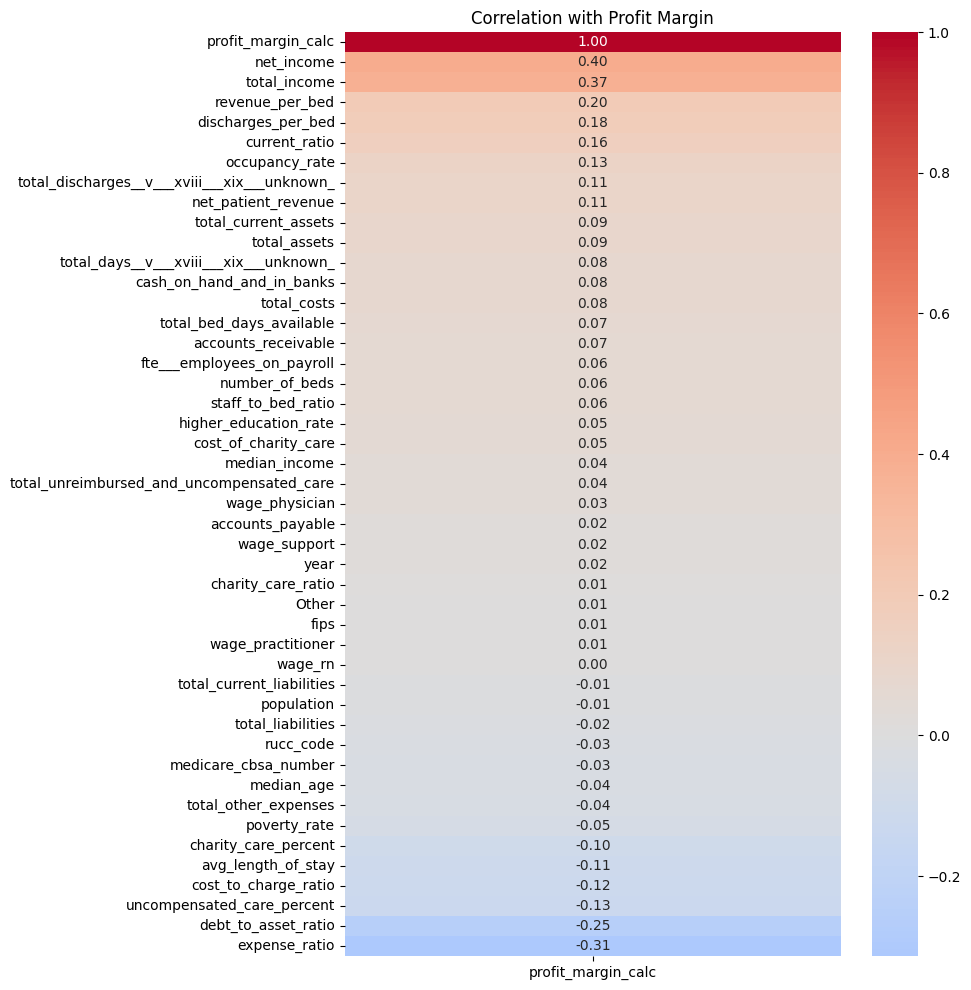

In [8]:
# Create correlation matrix for numeric columns
corr_matrix = ml_dataset.corr(numeric_only=True)

# Select correlations with Profit Margin
pm_corr = corr_matrix[['profit_margin_calc']].sort_values(
    by='profit_margin_calc',
    ascending=False
)

# Print correlations
print("Correlation with Profit Margin:")
print(pm_corr.round(2))

# Plot heatmap
plt.figure(figsize=(8, 12))
sns.heatmap(pm_corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation with Profit Margin')
plt.show()

Correlation with Charity Care Ratio:
                                              charity_care_ratio
charity_care_ratio                                          1.00
cost_of_charity_care                                        0.54
charity_care_percent                                        0.39
total_unreimbursed_and_uncompensated_care                   0.35
total_discharges__v___xviii___xix___unknown_                0.17
discharges_per_bed                                          0.16
number_of_beds                                              0.15
total_bed_days_available                                    0.15
total_days__v___xviii___xix___unknown_                      0.14
uncompensated_care_percent                                  0.12
fte___employees_on_payroll                                  0.12
total_costs                                                 0.11
accounts_receivable                                         0.11
net_patient_revenue                                  

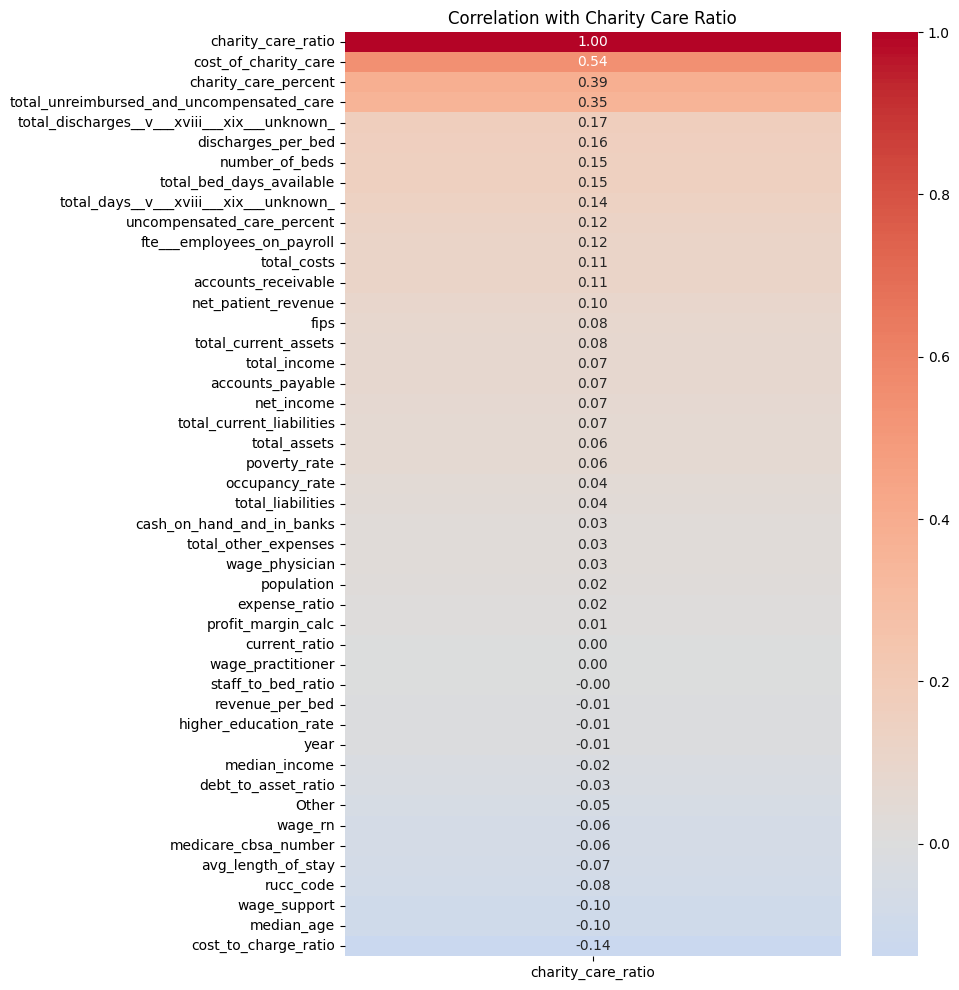

In [9]:
# Create correlation matrix for numeric columns
corr_matrix = ml_dataset.corr(numeric_only=True)

# Select correlations with CCR
ccr_corr = corr_matrix[['charity_care_ratio']].sort_values(
    by='charity_care_ratio',
    ascending=False
)

# Print correlations
print("Correlation with Charity Care Ratio:")
print(ccr_corr.round(2))

# Plot heatmap
plt.figure(figsize=(8, 12))
sns.heatmap(ccr_corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation with Charity Care Ratio')
plt.show()

## Correlation Analysis Results

Correlation analysis was performed to understand how different variables relate to the two target variables:

- Profit Margin  
- Charity Care Ratio (CCR)

Only numeric variables were used to ensure accurate statistical relationships.

# 1. Profit Margin Correlation

## Strong Positive Relationships

### Net Income (0.40)
Profit margin increases when net income increases.  
This is expected because profit margin is directly influenced by income.

### Total Income (0.37)
Hospitals earning higher total revenue tend to have better profit margins.

### Revenue per Bed (0.20)
Hospitals generating more revenue per bed usually operate more efficiently and show better profitability.

### Discharges per Bed (0.18)
Higher patient throughput per bed improves hospital financial performance.

### Current Ratio (0.16)
Hospitals with better liquidity tend to maintain higher profitability.

## Negative Relationships

### Expense Ratio (-0.31)
Higher expenses compared to revenue strongly reduce profit margin.

### Debt-to-Asset Ratio (-0.25)
Hospitals with higher debt levels generally show lower profitability.

### Cost-to-Charge Ratio (-0.12)
Higher treatment costs relative to patient charges reduce financial performance.

### Uncompensated Care Percent (-0.13)
Providing more unpaid care slightly reduces hospital profitability.

## Socioeconomic Influence

Community variables like poverty rate and education level show weak relationships, suggesting internal hospital efficiency is more important for profit margin.

# 2. Charity Care Ratio (CCR) Correlation

## Strong Positive Relationships

### Cost of Charity Care (0.54)
Hospitals spending more on charity care show higher CCR values.  
This variable is closely linked to CCR calculation.

### Charity Care Percent (0.39)
This variable measures a similar concept to CCR and shows strong association.

### Total Unreimbursed and Uncompensated Care (0.35)
Hospitals providing more unpaid care services show higher CCR values.

## Hospital Size and Service Volume

Moderate positive relationships were found with:

- Number of beds  
- Total discharges  
- Staffing levels  

Larger hospitals and those treating more patients tend to provide more charity care.

## Financial Variables

Financial scale variables such as total costs and revenue show small positive relationships with CCR.

## Community Factors

Poverty rate shows a small positive relationship, suggesting hospitals in lower-income communities provide more charity care.

## Negative Relationships

### Cost-to-Charge Ratio (-0.14)
Hospitals operating more efficiently tend to have slightly lower CCR.

### Workforce and Demographics
Variables like support staff wages and population age show small negative relationships with CCR.

# 3. Target Leakage Observation

Several CCR-related variables are directly connected to charity care accounting.  
These variables may artificially increase model accuracy and will need to be removed in advanced modelling.

# Overall Summary

- Profit margin is mainly influenced by hospital financial efficiency and expense control.
- CCR is strongly influenced by charity care spending and hospital size.
- Socioeconomic factors provide additional but smaller influence.
- Some CCR predictors indicate possible target leakage and require further filtering.

In [10]:
# Basic dataset overview
print("Dataset Shape:", ml_dataset.shape)
print("Missing values?", ml_dataset.isnull().values.any())
print("Duplicate rows:", ml_dataset.duplicated().sum())

# Target Variable Summaries
print("\n Profit Margin Summary")
print(ml_dataset['profit_margin_calc'].describe())

print("\n Charity Care Ratio Summary")
print(ml_dataset['charity_care_ratio'].describe())

Dataset Shape: (69555, 51)
Missing values? False
Duplicate rows: 1195

 Profit Margin Summary
count    69555.000000
mean         0.038973
std          0.183009
min         -0.899297
25%         -0.017782
50%          0.046184
75%          0.120533
max          0.520817
Name: profit_margin_calc, dtype: float64

 Charity Care Ratio Summary
count    69555.000000
mean         0.025685
std          0.029030
min          0.000176
25%          0.010362
50%          0.016959
75%          0.027327
max          0.184271
Name: charity_care_ratio, dtype: float64


In [11]:
# Dropping duplicates
ml_dataset.drop_duplicates(inplace=True)

In [12]:
# Creating a numeric columns dataset
numeric_columns = ml_dataset.select_dtypes(include=[np.number]).columns
baseline_numeric_df = ml_dataset[numeric_columns]
print("Number of Numeric Columns:", len(numeric_columns))

Number of Numeric Columns: 46


## 6. Baseline Dataset Construction

To maintain simplicity and interpretability, baseline modelling used **numeric variables only**.

Categorical variables were temporarily excluded to create a clean baseline benchmark.

This resulted in:

- 46 numeric predictor variables  
- Two separate target variables  

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [14]:
# Profit Margin Feature Selection

pm_drop_cols = [
    'profit_margin_calc',   # Target variable
    'net_income',           # Used in profit margin formula
    'total_income',         # Used in profit margin formula
    'expense_ratio'         # Strong inverse of profit margin
]

X_pm = baseline_numeric_df.drop(columns=pm_drop_cols)
y_pm = baseline_numeric_df['profit_margin_calc']


In [15]:
print("Feature Shape:", X_pm.shape)
print("Target Shape:", y_pm.shape)

Feature Shape: (68360, 42)
Target Shape: (68360,)


In [16]:
# Splitting the data into train and test
X_pm_train, X_pm_test, y_pm_train, y_pm_test = train_test_split(X_pm, y_pm, test_size=0.2, random_state=42)
print("Train Data Shape:", X_pm_train.shape, y_pm_train.shape)
print("Test Data Shape:", X_pm_test.shape, y_pm_test.shape)

Train Data Shape: (54688, 42) (54688,)
Test Data Shape: (13672, 42) (13672,)


In [17]:
# Running the models for Profit Margin Prediction
models = {
    'Linear Regression': LinearRegression(),
    'K-Nearest Neighbors': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(),

}

# Storing results
results = []

for model_name, model in models.items():

    # Train model
    model.fit(X_pm_train, y_pm_train)

    # Predictions
    y_train_pred = model.predict(X_pm_train)
    y_test_pred = model.predict(X_pm_test)

    # Metrics
    train_r2 = r2_score(y_pm_train, y_train_pred)
    test_r2 = r2_score(y_pm_test, y_test_pred)

    train_mse = mean_squared_error(y_pm_train, y_train_pred)
    test_mse = mean_squared_error(y_pm_test, y_test_pred)

    # Save results
    results.append({
        "Model": model_name,
        "Train R2": round(train_r2, 3),
        "Test R2": round(test_r2, 3),
        "Train MSE": round(train_mse, 5),
        "Test MSE": round(test_mse, 5)
    })


# Convert to DataFrame
results_df = pd.DataFrame(results)

# Display results
results_df
results_df.sort_values(by="Test R2", ascending=False)

,Model,Train R2,Test R2,Train MSE,Test MSE
1,K-Nearest Neighbors,0.598,0.370,0.01371,0.02000
0,Linear Regression,0.189,0.189,0.02767,0.02573
2,Decision Tree,1.000,-0.062,0.00000,0.03372


### Profit Margin Model Interpretation

Three baseline models were evaluated to predict hospital profit margin.

**K-Nearest Neighbors (KNN)**
- Best performance (Test R² = 0.37).
- Captures similarity patterns between hospitals.
- Slight overfitting observed as training performance is higher than testing.

**Linear Regression**
- Moderate performance (Test R² = 0.19).
- Stable results with no overfitting.
- Indicates profit margin is partly influenced by linear financial relationships.

**Decision Tree**
- Perfect training performance but poor testing performance.
- Negative test R² indicates severe overfitting.
- Model memorized training data and failed to generalize.

**Overall Insight**
Profit margin is influenced by complex nonlinear hospital characteristics. KNN provided the strongest baseline performance, while linear regression offered stable but limited predictive ability.


In [18]:
!pip install rfpimp


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
from rfpimp import permutation_importances, plot_importances
# Train Random Forest
rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_pm_train, y_pm_train)

# Predictions
y_train_pred = rf_model.predict(X_pm_train)
y_test_pred = rf_model.predict(X_pm_test)

# Performance Metrics
print("Random Forest Performance")
print("Train R2:", round(r2_score(y_pm_train, y_train_pred), 3))
print("Test R2:", round(r2_score(y_pm_test, y_test_pred), 3))
print("Train MSE:", round(mean_squared_error(y_pm_train, y_train_pred), 5))
print("Test MSE:", round(mean_squared_error(y_pm_test, y_test_pred), 5))

# rfpimp Permutation Importance
def r2(model, X, y):
    return r2_score(y, model.predict(X))
imp = permutation_importances(
    rf_model,
    X_pm_test,
    y_pm_test,
    r2
)

Random Forest Performance
Train R2: 0.927
Test R2: 0.488
Train MSE: 0.00248
Test MSE: 0.01623


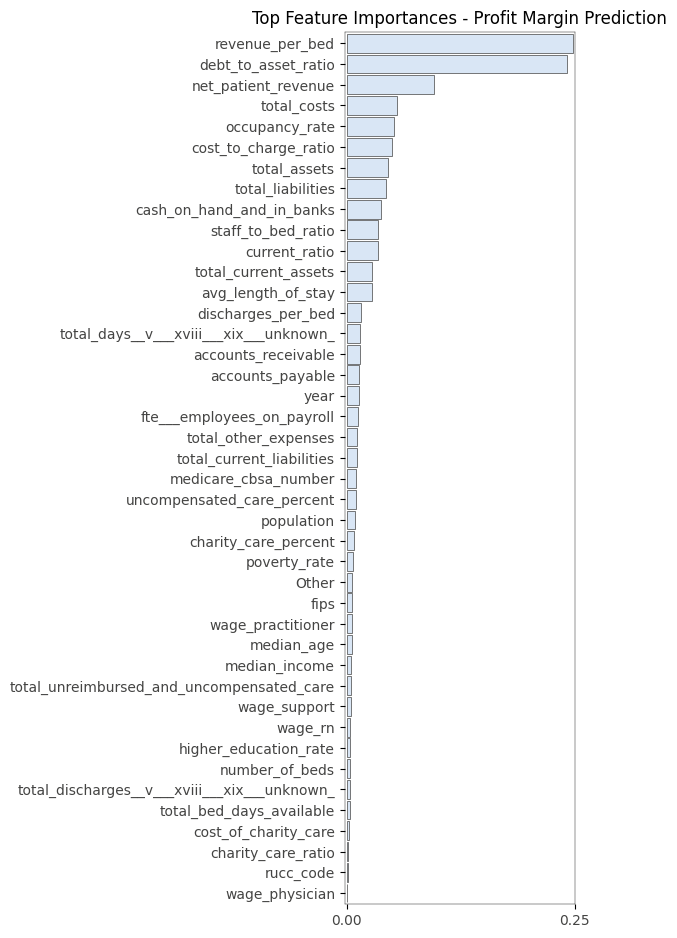

In [23]:
plt.figure(figsize=(14, 10))  # Increase width

plot_importances(imp)

plt.title("Top Feature Importances - Profit Margin Prediction")

# Increase space for long feature names
plt.subplots_adjust(left=0.35)

plt.show()

The Random Forest model showed the best performance for predicting hospital profit margin.

- The model explains about **49% of the variation** in profit margin.
- Training performance is very high, while testing performance is lower, indicating **moderate overfitting**, which is expected in tree-based ensemble models.

### Key Factors Influencing Profit Margin

Based on the updated feature importance plot, the strongest predictors include:

- **Revenue per Bed** – Hospitals generating higher revenue from available bed capacity tend to have stronger profit margins.
- **Debt-to-Asset Ratio** – Financial leverage plays a major role in determining hospital profitability and financial risk.
- **Net Patient Revenue** – Higher patient service revenue contributes significantly to financial performance.
- **Occupancy Rate** – Efficient bed utilization supports revenue generation and profitability.
- **Current Ratio and Financial Liquidity** – Hospitals with stronger short-term financial stability tend to maintain better margins.
- **Cost-to-Charge Ratio and Total Costs** – Operational cost efficiency directly impacts profitability.
- **Staff-to-Bed Ratio and Length of Stay** – Workforce utilization and patient management efficiency influence financial outcomes.

### Overall Insight

The results indicate that hospital profit margin is primarily driven by revenue efficiency, financial structure, operational utilization, and cost management. Community and demographic variables play a smaller role compared to internal hospital financial and operational performance. Random Forest successfully captures these complex and nonlinear relationships, making it the strongest predictive model among the tested approaches.

In [24]:
ccr_drop = [
    'charity_care_ratio',                # Target
    'cost_of_charity_care',              # CCR numerator
    'charity_care_percent',              # Redundant CCR metric
    'total_unreimbursed_and_uncompensated_care',  # CCR accounting total
    'uncompensated_care_percent',        # Derived uncompensated care metric
    'total_costs',                       # CCR denominator risk
    'net_patient_revenue',               # Financial denominator proxy
    'total_income',                      # Financial reconstruction risk
    'net_income',                        # Income-derived metric
    'expense_ratio'                      # Optional leakage protection
]

X_ccr = baseline_numeric_df.drop(columns=ccr_drop)
y_ccr = baseline_numeric_df['charity_care_ratio']

In [25]:
print("CCR Feature Shape:", X_ccr.shape)
print("CCR Target Shape:", y_ccr.shape)

CCR Feature Shape: (68360, 36)
CCR Target Shape: (68360,)


In [26]:
# Splitting into Train Test for Charity Care Ratio
X_ccr_train, X_ccr_test, y_ccr_train, y_ccr_test = train_test_split(X_ccr, y_ccr, test_size=0.2, random_state=42)
print("Train Data Shape:", X_ccr_train.shape, y_ccr_train.shape)
print("Test Data Shape:", X_ccr_test.shape, y_ccr_test.shape)

Train Data Shape: (54688, 36) (54688,)
Test Data Shape: (13672, 36) (13672,)


In [27]:
# Running the models for Charity Care Ratio Prediction
models = {
    'Linear Regression': LinearRegression(),
    'K-Nearest Neighbors': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(),

}

# Storing results
results_ccr = []

for model_name, model in models.items():

    # Train model
    model.fit(X_ccr_train, y_ccr_train)

    # Predictions
    y_train_pred = model.predict(X_ccr_train)
    y_test_pred = model.predict(X_ccr_test)

    # Metrics
    train_r2 = r2_score(y_ccr_train, y_train_pred)
    test_r2 = r2_score(y_ccr_test, y_test_pred)

    train_mse = mean_squared_error(y_ccr_train, y_train_pred)
    test_mse = mean_squared_error(y_ccr_test, y_test_pred)

    # Save results
    results_ccr.append({
        "Model": model_name,
        "Train R2": round(train_r2, 3),
        "Test R2": round(test_r2, 3),
        "Train MSE": round(train_mse, 5),
        "Test MSE": round(test_mse, 5)
    })


# Convert to DataFrame
results_ccr_df = pd.DataFrame(results_ccr)

# Display results
results_ccr_df
results_ccr_df.sort_values(by="Test R2", ascending=False)

,Model,Train R2,Test R2,Train MSE,Test MSE
2,Decision Tree,1.000,0.161,0.00000,0.00073
1,K-Nearest Neighbors,0.429,0.136,0.00048,0.00075
0,Linear Regression,0.094,0.102,0.00077,0.00078


### Charity Care Ratio (CCR) Model Interpretation

Three baseline models were tested to predict CCR.

**Decision Tree**
- Highest test performance (R² = 0.15).
- Perfect training score shows overfitting.
- Indicates CCR follows nonlinear hospital patterns.

**K-Nearest Neighbors (KNN)**
- Moderate performance (R² = 0.136).
- Shows CCR is influenced by similarity between hospitals.
- Slight overfitting observed.

**Linear Regression**
- Lowest performance (R² ≈ 0.10).
- Stable results with no overfitting.
- Shows CCR is not strongly explained by linear relationships.

**Overall Insight**
CCR prediction requires nonlinear modelling approaches. Tree-based models perform better but need tuning to reduce overfitting.

In [28]:
from rfpimp import permutation_importances, plot_importances

# Train Random Forest
rf_model_ccr = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_model_ccr.fit(X_ccr_train, y_ccr_train)


# Predictions
y_train_pred = rf_model_ccr.predict(X_ccr_train)
y_test_pred = rf_model_ccr.predict(X_ccr_test)


# Performance Metrics
print("Random Forest Performance - CCR Prediction")
print("Train R2:", round(r2_score(y_ccr_train, y_train_pred), 3))
print("Test R2:", round(r2_score(y_ccr_test, y_test_pred), 3))
print("Train MSE:", round(mean_squared_error(y_ccr_train, y_train_pred), 5))
print("Test MSE:", round(mean_squared_error(y_ccr_test, y_test_pred), 5))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_ccr_test, y_test_pred)), 5))

# Permutation Importance
def r2(model, X, y):
    return r2_score(y, model.predict(X))


imp_ccr = permutation_importances(
    rf_model_ccr,
    X_ccr_test,
    y_ccr_test,
    r2
)

# Sort importance
imp_ccr = imp_ccr.sort_values(by="Importance", ascending=False)

Random Forest Performance - CCR Prediction
Train R2: 0.94
Test R2: 0.608
Train MSE: 5e-05
Test MSE: 0.00034
Test RMSE: 0.01843


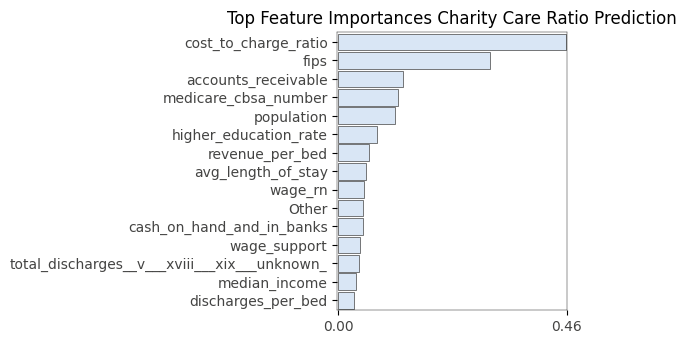

In [30]:
# Select Top Features
top_features_ccr = imp_ccr.head(15)

plt.figure(figsize=(14, 10))

plot_importances(top_features_ccr)

# Add spacing for long labels
plt.subplots_adjust(left=0.35)

plt.title("Top Feature Importances Charity Care Ratio Prediction")

plt.show()

The Random Forest model showed strong performance in predicting Charity Care Ratio (CCR).

- The model explains about **61% of the variation** in CCR.
- Training performance is very high, while testing performance is lower, indicating **moderate overfitting**, which is common in ensemble tree-based models.
- Low MSE and RMSE values indicate small prediction errors and reliable model performance.

### Key Factors Influencing Charity Care Ratio

The most important predictors include:

- **Cost-to-Charge Ratio** – Hospitals with higher treatment costs relative to charges tend to provide higher levels of charity care.
- **Geographic Location (FIPS and CBSA region)** – Charity care varies across regions, indicating strong community and policy influences.
- **Accounts Receivable** – Patient payment patterns and financial management affect uncompensated care levels.
- **Population and Education Levels** – Community socioeconomic conditions influence demand for charity care.
- **Hospital Operational Efficiency** – Length of stay, revenue per bed, and discharge efficiency contribute to charity care patterns.

### Overall Insight

Charity care ratio is influenced by hospital financial efficiency, regional healthcare demand, and community socioeconomic characteristics. Random Forest effectively captures these complex and nonlinear relationships, making it the strongest predictive model among those evaluated.


## Final Summary and Key Insights

Baseline machine learning models were developed to predict hospital profit margin and charity care ratio. Random Forest models demonstrated the strongest predictive performance, capturing nonlinear relationships between hospital financial efficiency, operational utilization, and community characteristics.

The results indicate that profit margin is primarily influenced by internal hospital financial and operational factors, while charity care ratio is strongly influenced by regional and socioeconomic characteristics. The integration of external datasets such as Census and workforce wage data improved predictive capability and provided additional context for healthcare demand.

## Limitations

The baseline models do not include categorical encoding or advanced hyperparameter tuning, which may limit predictive performance. Additionally, some financial variables may have accounting relationships with target variables, which may influence feature importance interpretation.

## Future Work

Future modelling steps may include:
- Encoding categorical variables
- Hyperparameter tuning and model optimization
- Advanced explainability techniques such as SHAP analysis
- Comparative modelling using enriched feature sets

##### Advanced Feature Selection

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score


# Profit Margin Feature Selection

rf_pm = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Sequential Feature Selection
sfs_pm = SequentialFeatureSelector(
    rf_pm,
    n_features_to_select=15,
    direction='forward',
    scoring='r2',
    cv=3,
    n_jobs=-1
)

sfs_pm.fit(X_pm_train, y_pm_train)

# Selected Features
pm_selected_features = X_pm_train.columns[sfs_pm.get_support()]

print("Selected Profit Margin Features:")
print(list(pm_selected_features))


# Create New Dataset With Selected Features
X_pm_train_selected = X_pm_train[pm_selected_features]
X_pm_test_selected = X_pm_test[pm_selected_features]


# Cross-Validation Performance Check
rf_pm.fit(X_pm_train_selected, y_pm_train)

cv_scores_pm = cross_val_score(
    rf_pm,
    X_pm_train_selected,
    y_pm_train,
    cv=5,
    scoring='r2'
)

print("\nProfit Margin Cross-Validated R2 Scores:", cv_scores_pm)
print("Average CV R2:", round(np.mean(cv_scores_pm), 3))

In [ ]:
rf_pm.fit(X_pm_train_selected, y_pm_train)

y_pm_pred = rf_pm.predict(X_pm_test_selected)

from sklearn.metrics import r2_score, mean_squared_error

print("Profit Margin Final Test R2:", r2_score(y_pm_test, y_pm_pred))
print("Profit Margin RMSE:", np.sqrt(mean_squared_error(y_pm_test, y_pm_pred)))

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# CCR Feature Selection

rf_ccr = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

sfs_ccr = SequentialFeatureSelector(
    rf_ccr,
    n_features_to_select=15,
    direction='forward',
    scoring='r2',
    cv=3,
    n_jobs=-1
)

sfs_ccr.fit(X_ccr_train, y_ccr_train)

# Selected Features
ccr_selected_features = X_ccr_train.columns[sfs_ccr.get_support()]

print("Selected CCR Features:")
print(list(ccr_selected_features))

# Create Selected Dataset
X_ccr_train_selected = X_ccr_train[ccr_selected_features]
X_ccr_test_selected = X_ccr_test[ccr_selected_features]


# Cross-Validation Performance Check
rf_ccr.fit(X_ccr_train_selected, y_ccr_train)

cv_scores_ccr = cross_val_score(
    rf_ccr,
    X_ccr_train_selected,
    y_ccr_train,
    cv=5,
    scoring='r2'
)

print("\nCCR Cross-Validated R2 Scores:", cv_scores_ccr)
print("Average CV R2:", round(np.mean(cv_scores_ccr), 3))


In [ ]:
rf_ccr.fit(X_ccr_train_selected, y_ccr_train)

y_ccr_pred = rf_ccr.predict(X_ccr_test_selected)

print("CCR Final Test R2:", r2_score(y_ccr_test, y_ccr_pred))
print("CCR RMSE:", np.sqrt(mean_squared_error(y_ccr_test, y_ccr_pred)))